# OCR Letter Recognition using Multiclass DNN

**Objective:** Implement a Deep Neural Network to classify letters (A-Z) based on numeric features from the Letter Recognition dataset.

In [1]:
%pip install pandas numpy tensorflow scikit-learn matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load the Dataset

In [3]:
df = pd.read_csv('letter-recognition.csv')
print("Dataset Shape:", df.shape)
print(df.head())

# Separate features and target
X = df.drop('letter', axis=1)
y = df['letter']

Dataset Shape: (20000, 17)
  letter  xbox   ybox   width   height  onpix   xbar   ybar   x2bar  y2bar   \
0      T      2      8       3       5       1      8     13      0       6   
1      I      5     12       3       7       2     10      5      5       4   
2      D      4     11       6       8       6     10      6      2       6   
3      N      7     11       6       6       3      5      9      4       6   
4      G      2      1       3       1       1      8      6      6       6   

   xybar   x2ybar  xy2bar  xedge   xedgey  yedge   yedgex  
0       6      10       8       0       8       0       8  
1      13       3       9       2       8       4      10  
2      10       3       7       3       7       3       9  
3       4       4      10       6      10       2       8  
4       6       5       9       1       7       5      10  


### 2. Preprocess Data

In [4]:
# Encode labels (letters A-Z to integers 0-25)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 3. Build the DNN Model

In [5]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(26, activation='softmax') # 26 letters in the alphabet
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

D:\Samarth\B.E DY Patil Pimpri\BE SEM 8\LP5\bin\lib\lp5\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │           8,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 26)                  │           3,354 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 176,282 (688.60 KB)

 Trainable params: 176,282 (688.60 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the Model

In [6]:
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_split=0.2, 
                    verbose=1)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6515 - loss: 1.1709 - val_accuracy: 0.8125 - val_loss: 0.6008
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8239 - loss: 0.5570 - val_accuracy: 0.8778 - val_loss: 0.3999
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8670 - loss: 0.4108 - val_accuracy: 0.9084 - val_loss: 0.3041
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8943 - loss: 0.3238 - val_accuracy: 0.9175 - val_loss: 0.2581
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9101 - loss: 0.2732 - val_accuracy: 0.9272 - val_loss: 0.2384
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9208 - loss: 0.2367 - val_accuracy: 0.9381 - val_loss: 0.1857
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9286 - loss: 0.2135 - val_accuracy: 0.9406 - val_loss: 0.1772
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9362 - loss: 0.1891 - val_accuracy: 0.

### 5. Evaluate Performance

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9668 - loss: 0.1437

Test Accuracy: 96.68%


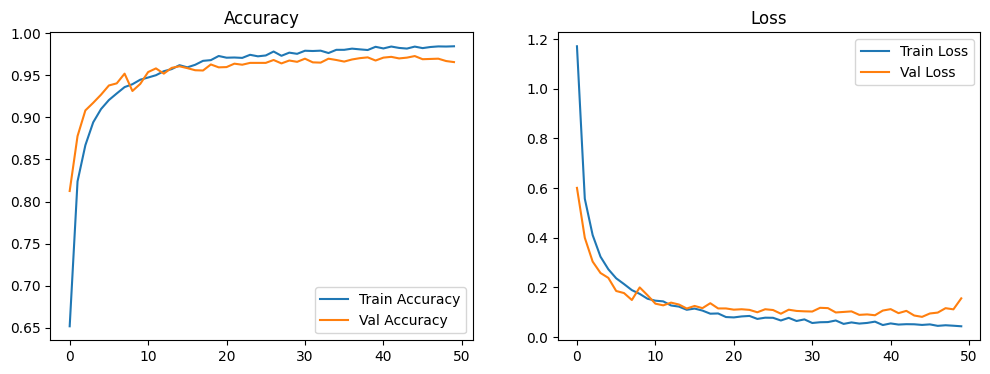

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

### 6. Classification Report

In [8]:
y_pred = np.argmax(model.predict(X_test), axis=-1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.99      1.00       149
           B       0.95      0.96      0.95       153
           C       0.97      0.96      0.97       137
           D       0.95      0.99      0.97       156
           E       0.96      0.97      0.96       141
           F       0.96      0.94      0.95       140
           G       0.97      0.98      0.98       160
           H       0.85      0.93      0.89       144
           I       0.95      0.96      0.95       146
           J       0.97      0.97      0.97       149
           K       0.95      0.95      0.95       130
           L       0.99      0.97      0.98       155
           M       0.97      0.99      0.98       168
           N       1.00      0.81      0.89       151
           O       0.97      0.99      0.98       145
           P       0.97      0.98      0.97       173
           Q    